# Ley de Paschen

### Joshua Briones Andrade

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_excel(r'./datos/Datosrotativo1.xlsx', sheet_name=[0,1,2], skiprows=[1], index_col=None)
df[0].head()

,Presion por distancia (20cm) [m*Torr],Voltaje [V]
0,0.00108,3150
1,0.00130,840
2,0.00148,520
3,0.00172,450
4,0.00178,413


In [3]:
pdist = []; voltaje = [];

for i in range(3):
    pdist.append(df[i].iloc[:,0].to_numpy())
    voltaje.append(df[i].iloc[:,1].to_numpy())

$$ V_r(pd) = \frac{B pd}{\text{ln}(pd)+P_1} $$

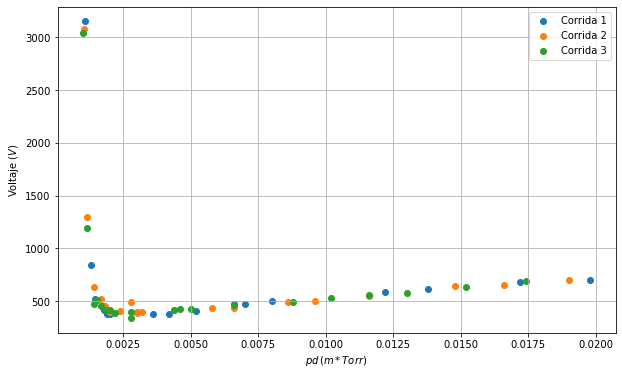

In [4]:
plt.figure(figsize=(10,6)); plt.grid()

labels = []
for k in range(3):
    labels.append("Corrida "+str(k+1))
    plt.scatter(pdist[k],voltaje[k], label=labels[k])

plt.xlabel(r"$pd\, (m*Torr)$")
plt.ylabel(r"Voltaje ($V$)")
plt.legend(); plt.show()


$$ P_1 = \ln\left(\frac{A}{\ln(1+1/\gamma)}\right) $$


In [5]:
B = 60; P = 6.915 

def V_r(X, B, P):
    t1 = B * X * 10000    #por 10 mil 
    t2 = np.log(X) + P
    return t1 / t2

def costo(k, B, P):
    return np.sum(np.abs(V_r(pdist[k], B, P) - voltaje[k]))/1000
    
costo(0, B, P)

34.162938695725934

In [6]:
from deap import tools
from deap import algorithms

def eaSimpleWithElitism(population, toolbox, cxpb, mutpb, ngen, stats=None,
             halloffame=None, verbose=__debug__):
    """This algorithm is similar to DEAP eaSimple() algorithm, with the modification that
    halloffame is used to implement an elitism mechanism. The individuals contained in the
    halloffame are directly injected into the next generation and are not subject to the
    genetic operators of selection, crossover and mutation.
    """
    logbook = tools.Logbook()
    logbook.header = ['gen', 'nevals'] + (stats.fields if stats else [])

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in population if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    if halloffame is None:
        raise ValueError("halloffame parameter must not be empty!")

    halloffame.update(population)
    hof_size = len(halloffame.items) if halloffame.items else 0

    record = stats.compile(population) if stats else {}
    logbook.record(gen=0, nevals=len(invalid_ind), **record)
    if verbose:
        print(logbook.stream)

    # Begin the generational process
    for gen in range(1, ngen + 1):

        # Select the next generation individuals
        offspring = toolbox.select(population, len(population) - hof_size)

        # Vary the pool of individuals
        offspring = algorithms.varAnd(offspring, toolbox, cxpb, mutpb)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # add the best back to population:
        offspring.extend(halloffame.items)

        # Update the hall of fame with the generated individuals
        halloffame.update(offspring)

        # Replace the current population by the offspring
        population[:] = offspring

        # Append the current generation statistics to the logbook
        record = stats.compile(population) if stats else {}
        logbook.record(gen=gen, nevals=len(invalid_ind), **record)
        if verbose:
            print(logbook.stream)

    return population, logbook

gen	nevals	min    	avg   
0  	1000  	94.7465	139876
1  	824   	88.0659	11530.4
2  	839   	52.465 	25094.8
3  	863   	51.1119	10655.9
4  	835   	51.1119	15073.2
5  	798   	48.9392	28919.1
6  	819   	46.401 	10655.9
7  	837   	46.401 	13280  
8  	837   	46.401 	58645.5
9  	843   	46.191 	65083.6
10 	837   	45.7695	309649 
11 	815   	45.3959	61528.4
12 	852   	45.3959	17141  
13 	828   	45.3778	152392 
14 	801   	45.3778	203337 
15 	838   	45.3662	100403 
16 	828   	45.3662	404505 
17 	804   	45.3638	33083.5
18 	818   	45.3638	61862.6
19 	820   	45.3631	41544.9
20 	868   	45.3625	89670.7
21 	837   	45.3625	22678.9
22 	816   	45.3625	39771.3
23 	819   	45.3625	1.61209e+08
24 	824   	45.3625	14536.9    
25 	811   	45.3625	659095     
26 	816   	45.3625	7278.76    
27 	848   	45.3625	41528.3    
28 	827   	45.3624	124643     
29 	820   	45.3624	1.8386e+06 
30 	813   	45.3624	17255.8    
31 	821   	45.3624	10656.5    
32 	829   	45.3624	17713.1    
33 	847   	45.3624	18335.6    
34 	806   	45

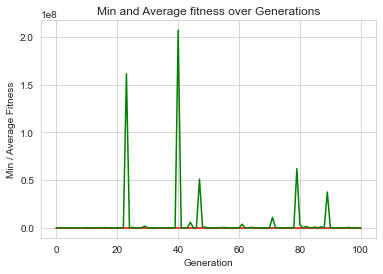

In [7]:
from deap import base, creator, tools

import random
import seaborn as sns
# import elitism

# problem constants:
DIMENSIONS = 2  # number of dimensions
BOUND_LOW, BOUND_UP = 6.5, 14  # boundaries for all dimensions

# Genetic Algorithm constants:
POPULATION_SIZE = 1000
P_CROSSOVER = 0.8  # probability for crossover
P_MUTATION = 0.25   # (try also 0.5) probability for mutating an individual
MAX_GENERATIONS = 100
HALL_OF_FAME_SIZE = 30
CROWDING_FACTOR = 25.0  # crowding factor for crossover and mutation

# set the random seed:

toolbox = base.Toolbox()

# define a single objective, minimizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMin)


# helper function for creating random real numbers uniformly distributed within a given range [low, up]
# it assumes that the range is the same for every dimension
def randomFloat(low, up):
    return [random.uniform(l, u) for l, u in zip([low] * DIMENSIONS, [up] * DIMENSIONS)]

# create an operator that randomly returns a float in the desired range and dimension:
toolbox.register("attrFloat", randomFloat, BOUND_LOW, BOUND_UP)

# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", tools.initIterate, creator.Individual, toolbox.attrFloat)

# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)


# Eggholder function as the given individual's fitness:
def costo(individual):
    B = individual[0]
    P = individual[1]
    f = np.sum((V_r(pdist[0], B, P) - voltaje[0])**2) / 1000
#     f = (-(y + 47.0) * np.sin(np.sqrt(abs(x/2.0 + (y + 47.0)))) - x * np.sin(np.sqrt(abs(x - (y + 47.0)))))
    return f,  # return a tuple

toolbox.register("evaluate", costo)

# genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=CROWDING_FACTOR)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=CROWDING_FACTOR, indpb=1.0/DIMENSIONS)


# Genetic Algorithm flow:
def main():

    # create initial population (generation 0):
    population = toolbox.populationCreator(n=POPULATION_SIZE)

    # prepare the statistics object:
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min)
    stats.register("avg", np.mean)

    # define the hall-of-fame object:
    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    # perform the Genetic Algorithm flow with elitism:
    population, logbook = eaSimpleWithElitism(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
                                              ngen=MAX_GENERATIONS, stats=stats, halloffame=hof, verbose=True)

    # print info for best solution found:
    best = hof.items[0]
    print("-- Best Individual = ", best)
    print("-- Best Fitness = ", best.fitness.values[0])

    # extract statistics:
    minFitnessValues, meanFitnessValues = logbook.select("min", "avg")

    # plot statistics:
    sns.set_style("whitegrid")
    plt.plot(minFitnessValues, color='red')
    plt.plot(meanFitnessValues, color='green')
    plt.xlabel('Generation')
    plt.ylabel('Min / Average Fitness')
    plt.title('Min and Average fitness over Generations')

    plt.show()


if __name__ == "__main__":
    main()

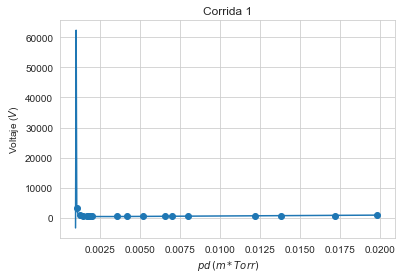

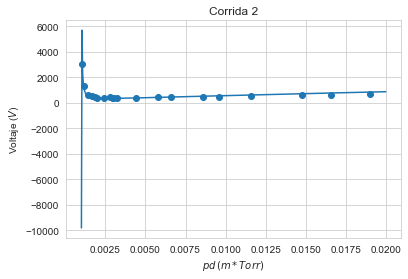

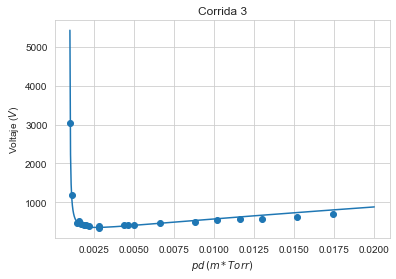

In [11]:
Coef = [];
Coef.append([12.162367348671193, 6.872409764926862])
Coef.append([13.156721632826208, 6.894332401842585])
Coef.append([13.294253127601706, 6.932251194144382])

X = np.linspace(0.001,0.02,500)

# plt.figure(figsize=(10,6)); plt.grid()

labels = []
for k in range(3):
    labels.append("Corrida "+str(k+1))
    # plt.scatter(pdist[k],voltaje[k], label=labels[k])
    plt.title(labels[k])
    plt.scatter(pdist[k],voltaje[k])
    plt.plot(X, V_r(X, Coef[k][0], Coef[k][1]));
    plt.xlabel(r"$pd\, (m*Torr)$")
    plt.ylabel(r"Voltaje ($V$)")
    # plt.legend(); 
    plt.show()
